In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [4]:
import pandas as pd

In [5]:
customers = pd.read_csv(path + "/olist_customers_dataset.csv")
geolocation = pd.read_csv(path + "/olist_geolocation_dataset.csv")
order_items = pd.read_csv(path + "/olist_order_items_dataset.csv")
orders = pd.read_csv(path + "/olist_orders_dataset.csv")
payments = pd.read_csv(path + "/olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "/olist_order_reviews_dataset.csv")

In [6]:
df = orders.merge(customers, on = "customer_id")
df = df.merge(payments, on = "order_id")

In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days = 1)

In [8]:
rfm = df.groupby('customer_unique_id').agg({'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
                                           'order_id' : 'nunique',
                                           'payment_value' : 'sum'}).reset_index()

### RFM Analysis Explained

RFM (Recency, Frequency, Monetary) analysis is a marketing technique used to quantitatively rank and segment customers based on their purchasing behavior. It helps identify a company's best customers by looking at:

*   **Recency (R):** How recently did the customer make a purchase? (The fewer days since their last purchase, the better).
*   **Frequency (F):** How often do they purchase? (The higher the number of purchases, the better).
*   **Monetary (M):** How much money do they spend? (The higher the total spend, the better).

In the code snippet `ek27SuvGuM0G`:

```python
rfm = df.groupby('customer_unique_id').agg({'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
                                           'order_id' : 'nunique',
                                           'payment_value' : 'sum'}).reset_index()
```

1.  **`df.groupby('customer_unique_id')`**: This groups the `df` DataFrame by `customer_unique_id`. This means that the subsequent aggregation will be performed for each unique customer.

2.  **`.agg({...})`**: This method applies multiple aggregation functions to different columns:

    *   **Recency (`order_purchase_timestamp`):**
        `lambda x: (snapshot_date - x.max()).days`
        This calculates the **Recency** for each customer. It finds the `maximum` (most recent) `order_purchase_timestamp` for each customer (`x.max()`). Then, it calculates the difference between a `snapshot_date` (which is typically a day after the latest purchase in the dataset) and this most recent purchase date. Finally, `.days` extracts the difference in days. A smaller number here means the customer purchased more recently.

    *   **Frequency (`order_id`):**
        `'order_id' : 'nunique'`
        This calculates the **Frequency** for each customer. It counts the number of `unique` `order_id`s for each customer. Each unique `order_id` represents a distinct purchase, so this tells us how many times a customer has purchased.

    *   **Monetary (`payment_value`):**
        `'payment_value' : 'sum'`
        This calculates the **Monetary** value for each customer. It sums up all the `payment_value`s for each customer, indicating the total amount of money they have spent.

3.  **`.reset_index()`**: After the `groupby` and `agg` operations, `customer_unique_id` would become the index of the resulting DataFrame. `reset_index()` converts `customer_unique_id` back into a regular column, making it easier to work with.

In [9]:
rfm.rename(columns = {'order_purchase_timestamp' : 'recency',
                      'order_id' : 'frequency',
                      'payment_value' : 'monetary'},
          inplace = True)

In [10]:
rfm['R_score'] = pd.qcut(rfm['recency'], q = 4, labels = [4,3,2,1])
rfm['M_score'] = pd.qcut(rfm['monetary'], q = 4, labels = [1,2,3,4])

def score_frequency(x):
  if x == 1: return 1
  elif x == 2: return 2
  elif x == 3: return 3
  else : return 4

rfm['F_score'] = rfm['frequency'].apply(score_frequency)

#combined score:
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [11]:
#Assining business segment:
def assign_business_segment(row):
  r = int(row['R_score'])
  f = int(row['F_score'])

  if r >= 3 and f >= 3:
    return 'Champions'
  elif r >= 2 and f >= 3:
    return 'Loyal Customers'
  elif r >= 3 and f == 2:
    return 'Potential Loyalist'
  elif r == 4 and f == 1:
    return 'Recent Customers'
  elif r == 3 and f == 1:
    return 'Promising'
  elif r == 2 and f == 2:
    return 'Needs Attention'
  elif r == 1 and f >= 3:
    return 'At Risk'
  elif r == 2 and f == 1:
    return 'Hibernating'
  else:
    return 'Lost'

#Applying on rfm:
rfm['Customer_Segment'] = rfm.apply(assign_business_segment, axis = 1)

In [12]:
segment_count = rfm['Customer_Segment'].value_counts()

segment_percentages = rfm['Customer_Segment'].value_counts(normalize = True) * 100

summary_df = pd.DataFrame({'Total_customers' : segment_count,
                           'Percentage(%)' : segment_percentages.round(2)})

In [13]:
summary_df

,Total_customers,Percentage(%)
Customer_Segment,,
Lost,23908,24.88
Hibernating,23339,24.29
Promising,23215,24.16
Recent Customers,23206,24.15
Potential Loyalist,1494,1.55
Needs Attention,681,0.71
Champions,160,0.17
Loyal Customers,47,0.05
At Risk,45,0.05


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#Revenue by each segment:
segment_revenue = rfm.groupby('Customer_Segment')['monetary'].sum().reset_index()

#Sorting of revenue in descending order:
segment_revenue = segment_revenue.sort_values(by = 'monetary', ascending = False)

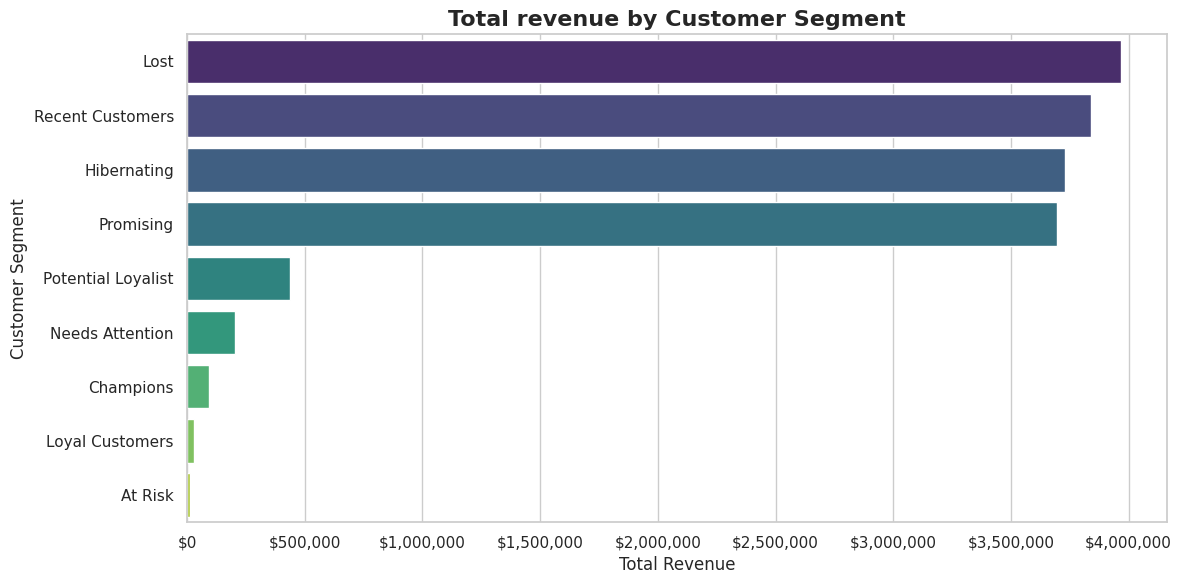

In [18]:
#setting the visual style:
sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (12,6))

#Horizontal bar chart:
ax = sns.barplot(
    data = segment_revenue,
    x = 'monetary',
    y = 'Customer_Segment',
    hue = 'Customer_Segment',
    palette = 'viridis',
    legend = False
)

plt.title('Total revenue by Customer Segment', fontsize = 16, fontweight = 'bold')
plt.xlabel('Total Revenue', fontsize = 12)
plt.ylabel('Customer Segment', fontsize = 12)

#Formatting the x-axis for better currency representation:
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))

plt.tight_layout()
plt.show()